<a href="https://colab.research.google.com/github/JMcKercher/Sentinel-1-SAR_SW-Australia/blob/main/S1_SAR_Seasonal_Indices_SW_WesternAustralia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Sentinel 1 SAR Seasonal Averages for the Walpole National Park Region & Surrounds


---



The below notebook will create Sentinel C-band Synthetic Aperture Radar (SAR) seasonal averages for the 4 seasons of the year over 9 years of available data. S1 SAR project data available within GEE is provided from 2014 onwards.

The idea is to calculate the seasonal average for each season of every year back to 2014 or the extent of data availability and then find the average of each season for the extent of the data period.

Less technically, an average of the each years season averages.

The Sentinel-1 mission provides data from a dual-polarization C-band Synthetic Aperture Radar (SAR) instrument at 5.405GHz (C band). This collection includes the S1 Ground Range Detected (GRD) scenes, processed using the Sentinel-1 Toolbox to generate a calibrated, ortho-corrected product. The collection is updated daily. New assets are ingested within two days after they become available. Imaging radars equipped with C-band are generally not hindered by atmospheric effects and are capable of imaging through tropical clouds and rain showers. Its penetration capability with regard to vegetation canopies or soils is limited and is restricted to the top layers.

***Polarisation***: The process of confining the vibrations of the magnetic, or electric field, vector of light or other radiation to one plane.

This collection contains all of the GRD scenes. Each scene has one of 3 resolutions (10, 25 or 40 meters), 4 band combinations (corresponding to scene polarization) and 3 instrument modes. Use of the collection in a mosaic context will likely require filtering down to a homogeneous set of bands and parameters.Each scene contains either 1 or 2 out of 4 possible polarization bands, depending on the instrument's polarization settings. The possible combinations are single band VV or HH, and dual band VV+VH and HH+HV:

1. VV: single co-polarization, **vertical transmit/vertical receive**
2. HH: single co-polarization, **horizontal transmit/horizontal receive**
3. VV + VH: dual-band cross-polarization, **vertical transmit/horizontal receive**
4. HH + HV: dual-band cross-polarization, **horizontal transmit/vertical receive**

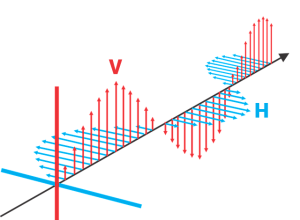

https://support.capellaspace.com/hc/en-us/articles/360044738831-Sentinel-1-Polarization#:~:text=VV%20is%20a%20mode%20that,vertical%20and%20horizontal%20wave%20patterns.

The primary conflict-free modes are IW, with VV+VH polarisation over land, and WV, with VV polarisation, over open ocean. EW mode is primarily used for wide area coastal monitoring including ship traffic, oil spill and sea-ice monitoring. SM mode is only used for small islands and on request for extraordinary events such as emergency management.Having the Interferometric Wide swath mode as the one main operational mode satisfies most current service requirements, avoids conflicts and preserves revisit performance, simplifies mission planning, decreases operational costs and builds up a consistent long-term archive.
IW acquires data with a 250 km swath at 5 m by 20 m spatial resolution (single look). IW mode captures three sub-swaths using Terrain Observation with Progressive Scans SAR (TOPSAR). With the TOPSAR technique, in addition to steering the beam in range as in ScanSAR, the beam is also electronically steered from backward to forward in the azimuth direction for each burst, avoiding scalloping and resulting in homogeneous image quality throughout the swath

To learn more: https://sentinel.esa.int/web/sentinel/user-guides/sentinel-1-sar/acquisition-modes

Each scene also includes an additional 'angle' band that contains the approximate incidence angle from ellipsoid in degrees at every point. This band is generated by interpolating the 'incidenceAngle' property of the 'geolocationGridPoint' gridded field provided with each asset.

https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S1_GRD#colab-python
https://sentinels.copernicus.eu/web/sentinel/user-guides/sentinel-1-sar/definitions

**Some draw backs to be aware of when using SAR:**


*   The coherent nature of the SAR microwave radiation causes speckle noise. This causes the "salt-and-pepper" appearance of extended target areas (e.g., a large homogeneous agricultural field) that one would expect to have a constant backscattering behavior. Speckle can be reduced in different ways, but is difficult to eliminate.
*   SAR backscattering depends on the angle of the incident microwave radiation. Thus, since the side-looking SAR operates over a range of incidence angles along the swath, the same target will appear different depending on whether it is in near range (low incidence angle) or far range (higher incidence angle) of the swath. The manner in which the backscattering varies with incidence angle depends on the target: a flat dry soil surface has a stronger drop off with incidence angle than, for instance, a forest.
*   Terrain relief has a strong effect on SAR backscattering because it modulates the area that is illuminated by the side-looking SAR radiation. Slope angle determines the orientation with respect to the incident radiation. This causes foreshortening for slopes oriented towards the SAR and shadowing of slopes steeper than the local incidence and directed away from the SAR.

**Sentinel-1 coverage**

Sentinel-1 consists of two identical sensors ("A" and "B") which have a 12-day revisit orbit each, but a 6-day revisit when combined. However, there are certain limitations to how much data can be acquired and downloaded from the two sensors, which depend on sensor uptime per orbit, ground station visibility for data downlinking and some other factors.

https://developers.google.com/earth-engine/tutorials/community/sar-basics



---




## Pre-start

In [ ]:
pip install geopandas

In [ ]:
pip install geemap

In [ ]:
pip install geemap[all]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.6/143.6 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.7/224.7 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 35.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.8/222.8 kB 22.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 24.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 68.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.3/346.3 kB 29.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd
#import geopandas as gpd
import os
import warnings
warnings.filterwarnings('ignore')
import geemap
import ee
ee.Authenticate()
ee.Initialize(project='project name')

## Sentinel 1 SAR data preparation and seasonal average calulation

### Acquire the imagery for the Area of Interest (AOI) and determine the seasonal dates

#### Define the AOI

In [ ]:
# Upload the AOI as a shapefile
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Or

In [ ]:
# Enter coordinates to create a rectangle around the AOI
geom = ee.Geometry.Polygon(
        [[[116.22429333713164,-35.08038467885357],
         [117.67174206760039,-35.08038467885357],
          [117.67174206760039,-34.43729474707892],
           [116.22429333713164,-34.43729474707892]]])
aoi = ee.Feature(geom)

# Or....  Access the Walpole Wilderness Area from my GGE assets
ww_aoi = ee.FeatureCollection('projects/ee-jmckercher/assets/Walpole_Wilderness')

#### Call the S1 data and outline the date range for the seasonal datasets

In [ ]:
def mask_edge(image):
  edge = image.lt(-30.0)
  masked_image = image.mask().And(edge.Not())
  return image.updateMask(masked_image)

# Call the S1 SAR data, includes VV and VH
S1_SAR = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(geom)
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('resolution_meters', 10)) # 10, 25, or 40
    .select('VV','VH')
    .map(mask_edge))

# 2023
sum_23 = ee.DateRange('2022-12-01', '2023-02-28')
aut_23 = ee.DateRange('2023-03-01', '2023-05-31')
win_23 = ee.DateRange('2023-06-01', '2023-08-31')
spr_23 = ee.DateRange('2023-09-01', '2023-11-30')
# 2022
sum_22 = ee.DateRange('2021-12-01', '2022-02-28')
aut_22 = ee.DateRange('2022-03-01', '2022-05-31')
win_22 = ee.DateRange('2022-06-01', '2022-08-31')
spr_22 = ee.DateRange('2022-09-01', '2022-11-30')
# 2021
sum_21 = ee.DateRange('2020-12-01', '2021-02-28')
aut_21 = ee.DateRange('2021-03-01', '2021-05-31')
win_21 = ee.DateRange('2021-06-01', '2021-08-31')
spr_21 = ee.DateRange('2021-09-01', '2021-11-30')
# 2020
sum_20 = ee.DateRange('2019-12-01', '2020-02-28')
aut_20 = ee.DateRange('2020-03-01', '2020-05-31')
win_20 = ee.DateRange('2020-06-01', '2020-08-31')
spr_20 = ee.DateRange('2020-09-01', '2020-11-30')
# 2019
sum_19 = ee.DateRange('2018-12-01', '2019-02-28')
aut_19 = ee.DateRange('2019-03-01', '2019-05-31')
win_19 = ee.DateRange('2019-06-01', '2019-08-31')
spr_19 = ee.DateRange('2019-09-01', '2019-11-30')
# 2018
sum_18 = ee.DateRange('2017-12-01', '2018-02-28')
aut_18 = ee.DateRange('2018-03-01', '2018-05-31')
win_18 = ee.DateRange('2018-06-01', '2018-08-31')
spr_18 = ee.DateRange('2018-09-01', '2018-11-30')
# 2017
sum_17 = ee.DateRange('2016-12-01', '2017-02-28')
aut_17 = ee.DateRange('2017-03-01', '2017-05-31')
win_17 = ee.DateRange('2017-06-01', '2017-08-31')
spr_17 = ee.DateRange('2017-09-01', '2017-11-30')
# 2016
sum_16 = ee.DateRange('2015-12-01', '2016-02-28')
aut_16 = ee.DateRange('2016-03-01', '2016-05-31')
win_16 = ee.DateRange('2016-06-01', '2016-08-31')
spr_16 = ee.DateRange('2016-09-01', '2016-11-30')
# 2015
sum_15 = ee.DateRange('2014-12-01', '2015-02-28')
aut_15 = ee.DateRange('2015-03-01', '2015-05-31')
win_15 = ee.DateRange('2015-06-01', '2015-08-31')
spr_15 = ee.DateRange('2015-09-01', '2015-11-30')

### Calculate the average for the seasonal averages

In [ ]:
# Summer
# Retrieve the seasonal images from each year and calulate the average
sar_sum_23 = S1_SAR.filterDate(sum_23); Ave_sum_23 = sar_sum_23.mean()
sar_sum_22 = S1_SAR.filterDate(sum_22); Ave_sum_22 = sar_sum_22.mean()
sar_sum_21 = S1_SAR.filterDate(sum_21); Ave_sum_21 = sar_sum_21.mean()
sar_sum_20 = S1_SAR.filterDate(sum_20); Ave_sum_20 = sar_sum_20.mean()
sar_sum_19 = S1_SAR.filterDate(sum_19); Ave_sum_19 = sar_sum_19.mean()
sar_sum_18 = S1_SAR.filterDate(sum_18); Ave_sum_18 = sar_sum_18.mean()
sar_sum_17 = S1_SAR.filterDate(sum_17); Ave_sum_17 = sar_sum_17.mean()
sar_sum_16 = S1_SAR.filterDate(sum_16); Ave_sum_16 = sar_sum_16.mean()
sar_sum_15 = S1_SAR.filterDate(sum_15); Ave_sum_15 = sar_sum_15.mean()

# merge the avergaed collections and calulate the mean of all images
Sum_Ave = ee.ImageCollection.fromImages([Ave_sum_23,
                                        Ave_sum_22,
                                        Ave_sum_21,
                                        Ave_sum_20,
                                        Ave_sum_19,
                                        Ave_sum_18,
                                        Ave_sum_17,
                                        Ave_sum_16,
                                        Ave_sum_15]) # merge the seasonal average images to a singular collection
S1_sum_a = Sum_Ave.mean() #calulate the mean of each seasonal averages
S1_Sum_Ave = S1_sum_a.clip(aoi) #clip it to the Walpole AOI

# Autumn
# Retrieve the seasonal images from each year and calulate the average
sar_aut_23 = S1_SAR.filterDate(sum_23); Ave_aut_23 = sar_aut_23.mean()
sar_aut_22 = S1_SAR.filterDate(sum_22); Ave_aut_22 = sar_aut_22.mean()
sar_aut_21 = S1_SAR.filterDate(sum_21); Ave_aut_21 = sar_aut_21.mean()
sar_aut_20 = S1_SAR.filterDate(sum_20); Ave_aut_20 = sar_aut_20.mean()
sar_aut_19 = S1_SAR.filterDate(sum_19); Ave_aut_19 = sar_aut_19.mean()
sar_aut_18 = S1_SAR.filterDate(sum_18); Ave_aut_18 = sar_aut_18.mean()
sar_aut_17 = S1_SAR.filterDate(sum_17); Ave_aut_17 = sar_aut_17.mean()
sar_aut_16 = S1_SAR.filterDate(sum_16); Ave_aut_16 = sar_aut_16.mean()
sar_aut_15 = S1_SAR.filterDate(sum_15); Ave_aut_15 = sar_aut_15.mean()

# merge the avergaed collections and calulate the mean of all images
Aut_Ave = ee.ImageCollection.fromImages([Ave_aut_23,
                                        Ave_aut_22,
                                        Ave_aut_21,
                                        Ave_aut_20,
                                        Ave_aut_19,
                                        Ave_aut_18,
                                        Ave_aut_17,
                                        Ave_aut_16,
                                        Ave_aut_15]) # merge the seasonal average images to a singular collection
S1_aut_a = Aut_Ave.mean() #calulate the mean of each seasonal averages
S1_Aut_Ave = S1_aut_a.clip(aoi) #clip it to the Walpole AOI

# Winter
# Retrieve the seasonal images from each year and calulate the average
sar_win_23 = S1_SAR.filterDate(win_23); Ave_win_23 = sar_win_23.mean()
sar_win_22 = S1_SAR.filterDate(win_22); Ave_win_22 = sar_win_22.mean()
sar_win_21 = S1_SAR.filterDate(win_21); Ave_win_21 = sar_win_21.mean()
sar_win_20 = S1_SAR.filterDate(win_20); Ave_win_20 = sar_win_20.mean()
sar_win_19 = S1_SAR.filterDate(win_19); Ave_win_19 = sar_win_19.mean()
sar_win_18 = S1_SAR.filterDate(win_18); Ave_win_18 = sar_win_18.mean()
sar_win_17 = S1_SAR.filterDate(win_17); Ave_win_17 = sar_win_17.mean()
sar_win_16 = S1_SAR.filterDate(win_16); Ave_win_16 = sar_win_16.mean()
sar_win_15 = S1_SAR.filterDate(win_15); Ave_win_15 = sar_win_15.mean()

# merge the avergaed collections and calulate the mean of all images
Win_Ave = ee.ImageCollection.fromImages([Ave_win_23,
                                        Ave_win_22,
                                        Ave_win_21,
                                        Ave_win_20,
                                        Ave_win_19,
                                        Ave_win_18,
                                        Ave_win_17,
                                        Ave_win_16,
                                        Ave_win_15]) # merge the seasonal average images to a singular collection
S1_win_a = Win_Ave.mean() #calulate the mean of each seasonal averages
S1_Win_Ave = S1_win_a.clip(aoi) #clip it to the Walpole AOI

# Spring
# Retrieve the seasonal images from each year and calulate the average
sar_spr_23 = S1_SAR.filterDate(spr_23); Ave_spr_23 = sar_spr_23.mean()
sar_spr_22 = S1_SAR.filterDate(spr_22); Ave_spr_22 = sar_spr_22.mean()
sar_spr_21 = S1_SAR.filterDate(spr_21); Ave_spr_21 = sar_spr_21.mean()
sar_spr_20 = S1_SAR.filterDate(spr_20); Ave_spr_20 = sar_spr_20.mean()
sar_spr_19 = S1_SAR.filterDate(spr_19); Ave_spr_19 = sar_spr_19.mean()
sar_spr_18 = S1_SAR.filterDate(spr_18); Ave_spr_18 = sar_spr_18.mean()
sar_spr_17 = S1_SAR.filterDate(spr_17); Ave_spr_17 = sar_spr_17.mean()
sar_spr_16 = S1_SAR.filterDate(spr_16); Ave_spr_16 = sar_spr_16.mean()
sar_spr_15 = S1_SAR.filterDate(spr_15); Ave_spr_15 = sar_spr_15.mean()

# merge the avergaed collections and calulate the mean of all images
Spr_Ave = ee.ImageCollection.fromImages([Ave_spr_23,
                                        Ave_spr_22,
                                        Ave_spr_21,
                                        Ave_spr_20,
                                        Ave_spr_19,
                                        Ave_spr_18,
                                        Ave_spr_17,
                                        Ave_spr_16,
                                        Ave_spr_15]) # merge the seasonal average images to a singular collection
S1_spr_a = Spr_Ave.mean() #calulate the mean of each seasonal averages
S1_Spr_Ave = S1_spr_a.clip(aoi) #clip it to the Walpole AOI

# Create a list of acquisition dates for each image in the season of choice
import time
# Update the first variable to the image collection corresponding to the season and year
acq_times = sar_spr_23.aggregate_array('system:time_start').getInfo()
[time.strftime('%x', time.gmtime(acq_time/1000)) for acq_time in acq_times]

['09/02/23',
 '09/09/23',
 '09/11/23',
 '09/14/23',
 '09/21/23',
 '09/23/23',
 '09/26/23',
 '10/03/23',
 '10/05/23',
 '10/08/23',
 '10/15/23',
 '10/17/23',
 '10/29/23',
 '11/01/23',
 '11/08/23',
 '11/10/23',
 '11/13/23',
 '11/20/23',
 '11/22/23',
 '11/25/23']

In [ ]:
x,y = geom.centroid().getInfo()['coordinates']
# call geemap for plotting
Map = geemap.Map(center=(y,x), zoom = 10)
Map.add_basemap('SATELLITE')

params = {'min': -25, 'max': 5}

Map.add_layer(S1_Sum_Ave, params, 'S1 SAR Summer Average - 2022')
Map.add_layer(S1_Aut_Ave, params, 'S1 SAR Autumn Average - 2022')
Map.add_layer(S1_Win_Ave, params, 'S1 SAR Winter Average - 2022')
Map.add_layer(S1_Spr_Ave, params, 'S1 SAR Spring Average - 2022')
Map.add_layer(ww_aoi, params, 'WNNP') # Add the WWNNP polygon
Map

Map(center=[-34.76056317494636, 116.94801770236589], controls=(WidgetControl(options=['position', 'transparent…

### Export Images

In [ ]:
task = ee.batch.Export.image.toDrive(**{
    'image': S1_Spr_Ave,
    'description': 'PEAT_S1_SAR_Spring_to2023',
    'folder':'Masters',
    'scale': 10,
    'region': aoi.getInfo()['geometry']['coordinates'],
    'maxPixels': 116000000
    })
task.start()

import time
while task.active():
  print('Polling for task (id: {}).'.format(task.id))
  time.sleep(20)

task.status()

Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id: HKR5U3KGZJK5VFAYH7IQBIT4).
Polling for task (id

{'state': 'COMPLETED',
 'description': 'PEAT_S1_SAR_Spring_to2023',
 'priority': 100,
 'creation_timestamp_ms': 1713159607360,
 'update_timestamp_ms': 1713160760018,
 'start_timestamp_ms': 1713160099747,
 'task_type': 'EXPORT_IMAGE',
 'destination_uris': ['https://drive.google.com/#folders/1grsggDH7uoU-oqS2sYG4Bq8QOBVRcLt8'],
 'attempt': 2,
 'batch_eecu_usage_seconds': 13567.26953125,
 'id': 'HKR5U3KGZJK5VFAYH7IQBIT4',
 'name': 'projects/peat-s1-sar-seasonal/operations/HKR5U3KGZJK5VFAYH7IQBIT4'}